# **TASK 1: PART A**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#mnist dataset
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data',train=False,download=True,transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.91MB/s]


In [ ]:
#custom CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(16*7*7, 32)
        self.fc2 = nn.Linear(32, 10)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 16*7*7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
#parameter check
model = CustomCNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)

Total parameters: 26698


In [ ]:
#loss func & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#training loop
train_losses = []
val_losses = []
train_acc = []
val_acc = []
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_losses.append(running_loss/len(train_loader))
    train_acc.append(correct/total)
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(val_loss/len(test_loader))
    val_acc.append(correct/total)
    print(f"Epoch {epoch+1}/{epochs} | Train Acc {train_acc[-1]:.4f} | Val Acc {val_acc[-1]:.4f}")

Epoch 1/10 | Train Acc 0.8972 | Val Acc 0.9694
Epoch 2/10 | Train Acc 0.9720 | Val Acc 0.9779
Epoch 3/10 | Train Acc 0.9794 | Val Acc 0.9830
Epoch 4/10 | Train Acc 0.9837 | Val Acc 0.9823
Epoch 5/10 | Train Acc 0.9863 | Val Acc 0.9853
Epoch 6/10 | Train Acc 0.9878 | Val Acc 0.9881
Epoch 7/10 | Train Acc 0.9897 | Val Acc 0.9873
Epoch 8/10 | Train Acc 0.9897 | Val Acc 0.9862
Epoch 9/10 | Train Acc 0.9910 | Val Acc 0.9875
Epoch 10/10 | Train Acc 0.9922 | Val Acc 0.9854


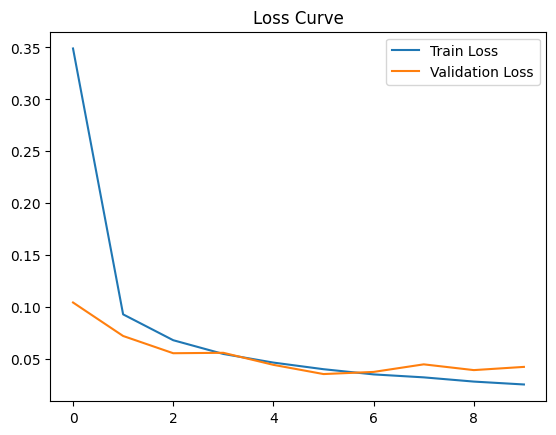

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

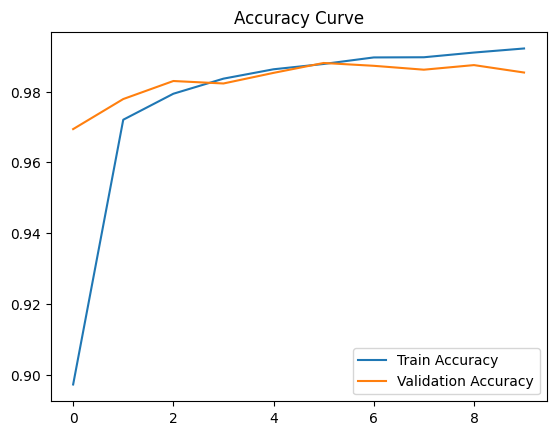

In [ ]:
plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
#test accuracy
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print("Final Test Accuracy:", correct/total)

Final Test Accuracy: 0.9854


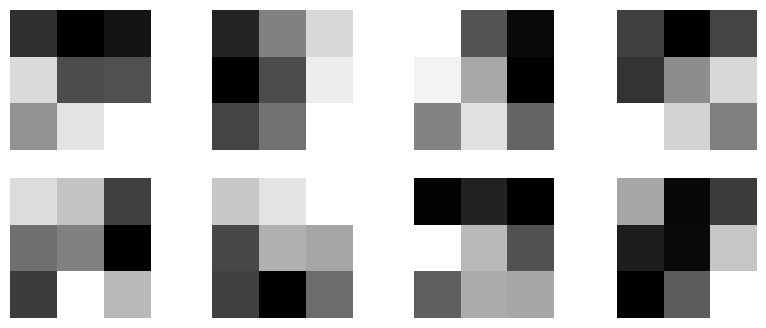

In [ ]:
#first convolutional filters
filters = model.conv1.weight.data.clone()
filters = filters - filters.min()
filters = filters / filters.max()
n_filters = filters.shape[0]
plt.figure(figsize=(10,4))
for i in range(n_filters):
    plt.subplot(2,4,i+1)
    plt.imshow(filters[i][0], cmap='gray')
    plt.axis('off')
plt.show()

# TASK 1: PART B

In [12]:
train_images, train_labels = torch.load("/content/train_biased.pt", map_location="cpu")

biased_test_images, biased_test_labels = torch.load("/content/test_biased.pt", map_location="cpu")

unbiased_test_images, unbiased_test_labels = torch.load("/content/test_unbiased.pt", map_location="cpu")

In [13]:
#dataset
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(train_images, train_labels)
biased_test_dataset = TensorDataset(biased_test_images, biased_test_labels)
unbiased_test_dataset = TensorDataset(unbiased_test_images, unbiased_test_labels)

In [14]:
#dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
biased_test_loader = DataLoader(biased_test_dataset, batch_size=64)
unbiased_test_loader = DataLoader(unbiased_test_dataset, batch_size=64)

In [15]:
#img shape
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([64, 3, 28, 28])


In [16]:
#model
import torch.nn as nn

class CustomCNN_RGB(nn.Module):
    def __init__(self):
        super(CustomCNN_RGB,self).__init__()
        self.conv1 = nn.Conv2d(3,8,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(8,16,kernel_size=3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(16*7*7,32)
        self.fc2 = nn.Linear(32,10)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1,16*7*7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
#initialize model
model = CustomCNN_RGB()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
#training loop
train_losses = []
train_acc = []
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images,labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _,predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    epoch_loss = running_loss/len(train_loader)
    epoch_acc = correct/total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs} | Loss:{epoch_loss:.4f} | Accuracy:{epoch_acc:.4f}")

Epoch 1/10 | Loss:0.2809 | Accuracy:0.9228
Epoch 2/10 | Loss:0.0790 | Accuracy:0.9781
Epoch 3/10 | Loss:0.0551 | Accuracy:0.9840
Epoch 4/10 | Loss:0.0442 | Accuracy:0.9876
Epoch 5/10 | Loss:0.0363 | Accuracy:0.9892
Epoch 6/10 | Loss:0.0312 | Accuracy:0.9903
Epoch 7/10 | Loss:0.0272 | Accuracy:0.9919
Epoch 8/10 | Loss:0.0240 | Accuracy:0.9925
Epoch 9/10 | Loss:0.0209 | Accuracy:0.9933
Epoch 10/10 | Loss:0.0188 | Accuracy:0.9939


In [19]:
#evaluation func
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images,labels in loader:
            outputs = model(images)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted==labels).sum().item()
    return correct/total

In [20]:
#evaluation on both test sets
biased_accuracy = evaluate(biased_test_loader)
unbiased_accuracy = evaluate(unbiased_test_loader)
print("Biased Test Accuracy:", biased_accuracy)
print("Unbiased Test Accuracy:", unbiased_accuracy)

Biased Test Accuracy: 0.9906
Unbiased Test Accuracy: 0.8859


# **TASK 2: PART A**

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [23]:
transform = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])

In [24]:
#dataset load
train_dataset = datasets.STL10(root="./data",split="train",download=True,transform=transform)
test_dataset = datasets.STL10(root="./data",split="test",download=True,transform=transform)

100%|██████████| 2.64G/2.64G [01:37<00:00, 27.2MB/s]


In [25]:
#dataloaders
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,num_workers=2)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False,num_workers=2)

In [26]:
#pretrained resnet-18 load
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


In [27]:
#backbone layers freezed
for param in model.parameters():
    param.requires_grad = False

In [28]:
#classification layer final
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

In [29]:
#loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(),lr=0.001)

In [30]:
#training
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.9508
Epoch [2/5], Loss: 0.3172
Epoch [3/5], Loss: 0.2418
Epoch [4/5], Loss: 0.1985
Epoch [5/5], Loss: 0.1753


In [33]:
#test set evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 94.45%


# **TASK 2: PART B**

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 37.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ae034e6a64b37e37d3718cf56e6e8971c7039156d5db18a028c52b4a4fc7b6c5
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#dataset load
transform = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
test_dataset = datasets.STL10(root="./data",split="test",download=True,transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

100%|██████████| 2.64G/2.64G [01:51<00:00, 23.7MB/s]


In [6]:
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 10)
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
#2 correct 2 incorrect predictions
correct_images = []
incorrect_images = []
for img, label in test_loader:
    img = img.to(device)
    label = label.to(device)
    output = model(img)
    pred = torch.argmax(output,1)
    if pred == label and len(correct_images) < 2:
        correct_images.append((img,label,pred))
    elif pred != label and len(incorrect_images) < 2:
        incorrect_images.append((img,label,pred))
    if len(correct_images) == 2 and len(incorrect_images) == 2:
        break
samples = correct_images + incorrect_images

In [9]:
#gradcam setup
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model,target_layers=target_layers)

In [19]:
#img converted for visualization
def denormalize(img):
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    # detach tensor first
    img = img.detach().cpu().numpy().transpose(1,2,0)
    img = std * img + mean
    img = np.clip(img,0,1)
    return img

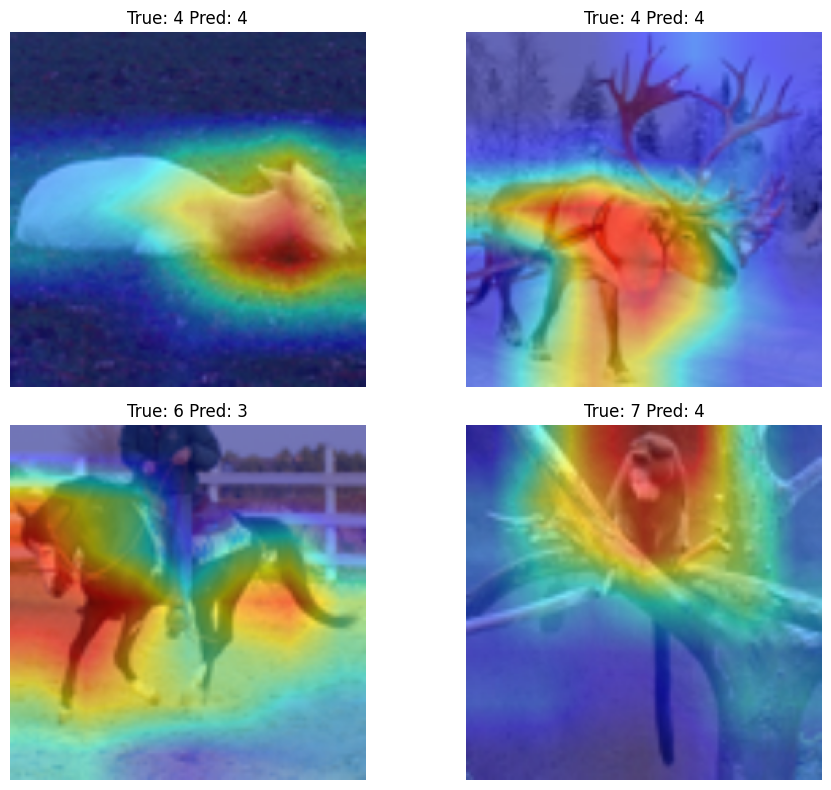

In [21]:
plt.figure(figsize=(10,8))
for i, (img, label, pred) in enumerate(samples):
    img_tensor = img.detach().to(device)
    img_tensor.requires_grad = True
    targets = [ClassifierOutputTarget(pred.item())]
    with torch.enable_grad():
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]
    original_img = denormalize(img_tensor[0])
    cam_image = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)
    plt.subplot(2,2,i+1)
    plt.imshow(cam_image)
    plt.axis("off")
    title = f"True: {label.item()} Pred: {pred.item()}"
    plt.title(title)
plt.tight_layout()
plt.show()